# Modelling – Predicting Student Grades

Notebook này là **bước tiếp theo sau `EDA_final.ipynb`** và đồng thời là bài hướng dẫn cách dùng model để dự đoán. Phần giải thích viết bằng tiếng Việt; phần **Conclusion** viết bằng tiếng Anh để bạn luyện viết report.

**Bạn sẽ học được:**
1. Quy trình chuẩn của một bài Machine Learning (supervised learning)
2. Chia train/test, tránh data leakage, dùng `Pipeline`
3. Đánh giá model regression: MAE, RMSE, R²
4. So sánh model tuyến tính (Linear, Ridge, Lasso) và model cây (Decision Tree, Random Forest, Gradient Boosting), thêm một neural network đơn giản
5. Cross-validation và tinh chỉnh hyperparameter
6. Giải thích model, dự đoán cho học sinh mới, lưu model
7. Bonus: bài toán classification (phát hiện học sinh có nguy cơ điểm thấp)

**Quy trình ML (nhớ thứ tự này):**

`Define problem → Split train/test → Preprocess (fit on train only) → Baseline → Train models → Cross-validate & compare → Tune → Final test evaluation → Interpret → Predict new data`

# 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42          # fixed seed -> results are reproducible

df = pd.read_csv('Gaming_Academic_Performance_clean.csv')   # cleaned data from EDA_final.ipynb
print(df.shape)
df.head()

(8000, 14)


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


# 1. Define the problem

> **Supervised learning** = học từ dữ liệu đã có đáp án. Có 2 loại:
> - **Regression**: dự đoán một **con số** (ví dụ `grades` = 72.5) → mục 1–13.
> - **Classification**: dự đoán một **nhãn** (ví dụ "at risk" / "not at risk") → mục 14.
> 
> Ta có **X** (features – thông tin đầu vào) và **y** (target – thứ cần dự đoán). Model học một hàm `y ≈ f(X)`.
> 
> **Chọn feature dựa trên EDA:**
> - Bỏ `student_id`: chỉ là mã số, không mang thông tin.
> - Bỏ `stress_level`: EDA cho thấy cột này được **tạo ra từ** study, sleep, gaming bằng một quy tắc. Dùng nó là "gian lận" (**data leakage**): trong thực tế, ta thường không có nhãn stress trước khi biết điểm.
> - Giữ tất cả các feature còn lại. Các model sẽ cho thấy feature nào thật sự có ích.

In [2]:
target = 'grades'
num_cols = ['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
            'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score']
cat_cols = ['gender', 'gaming_genre']
key_cols = ['study_hours', 'gaming_hours', 'sleep_hours', 'attendance']   # the 4 key features found in EDA

X = df[num_cols + cat_cols]
y = df[target]
print('X:', X.shape, '| y:', y.shape)

X: (8000, 11) | y: (8000,)


# 2. Train / test split

> **Tại sao phải chia?** Model phải được chấm điểm trên dữ liệu **nó chưa từng thấy**, giống như thi bằng đề mới chứ không phải đề đã chữa. Nếu chấm trên chính dữ liệu train, model "học thuộc" sẽ có điểm rất cao nhưng dùng thực tế thì kém (**overfitting**).
> 
> - **Train set (80%)**: dùng để học, so sánh model, tinh chỉnh.
> - **Test set (20%)**: **cất đi, chỉ dùng MỘT lần ở cuối** (mục 11) để báo cáo kết quả cuối cùng.
> - `random_state` cố định để lần chạy nào cũng chia giống nhau.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print(f'Mean grade - train: {y_train.mean():.2f}, test: {y_test.mean():.2f}')

Train: (6400, 11) | Test: (1600, 11)
Mean grade - train: 66.10, test: 65.98


**Conclusion:** The data was split into **6,400 training rows (80%)** and **1,600 test rows (20%)**. The mean grade is similar in both sets, so the split is balanced.

# 3. Preprocessing with Pipeline

> Model chỉ hiểu **số**, và một số model nhạy cảm với **thang đo** của dữ liệu:
> - **`OneHotEncoder`**: đổi chữ thành số. `gender = Male/Female/Other` → 2 cột 0/1 (`drop='first'` bỏ 1 cột để tránh thừa thông tin).
> - **`StandardScaler`**: đưa mỗi cột số về mean = 0, std = 1. Cần cho Linear/Ridge/Lasso/Neural network, vì `reaction_time_ms` (~270) và `gaming_hours` (~4) có thang đo rất khác nhau. Model cây **không cần** scale.
> - **`ColumnTransformer`**: áp dụng cách xử lý khác nhau cho từng nhóm cột.
> - **`Pipeline`**: nối "xử lý + model" thành **một object**. Gọi `.fit()` là nó tự fit scaler **chỉ trên train**, rồi mới train model.
> 
> ⚠️ **Data leakage:** nếu bạn `StandardScaler().fit(X)` trên **toàn bộ** dữ liệu trước khi chia, thông tin (mean, std) của test set sẽ "rò rỉ" vào model. `Pipeline` giúp tránh lỗi này tự động.

In [4]:
# For linear models / neural networks: scale numbers + one-hot encode text
prep_linear = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols),
])

# For tree models: no scaling needed, only encode text
prep_tree = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols),
])

# Only the 4 key features (other columns are dropped)
prep_key = ColumnTransformer([('num', StandardScaler(), key_cols)], remainder='drop')

# Look at what the model actually receives
prep_linear.fit(X_train)
pd.DataFrame(prep_linear.transform(X_train.head(3)),
             columns=prep_linear.get_feature_names_out()).round(2)

,num__age,num__gaming_hours,num__study_hours,num__sleep_hours,num__attendance,num__social_activity,num__device_usage,num__reaction_time_ms,num__addiction_score,cat__gender_Male,cat__gender_Other,cat__gaming_genre_FPS,cat__gaming_genre_RPG
0,1.56,-0.02,-1.59,0.30,-0.27,0.03,-0.74,-0.03,-0.10,1.0,0.0,1.0,0.0
1,0.40,-0.68,-0.34,-1.72,0.98,-0.72,0.10,0.66,-0.59,0.0,0.0,1.0,0.0
2,1.18,1.57,0.24,1.49,1.01,-0.13,0.73,-1.10,1.06,0.0,0.0,0.0,0.0


# 4. Evaluation metrics

Với regression, có 3 chỉ số phổ biến (trong đó $y_i$ là điểm thật, $\hat{y}_i$ là điểm dự đoán):

| Metric | Công thức | Ý nghĩa | Tốt khi |
| --- | --- | --- | --- |
| **MAE** | $\frac{1}{n}\sum \lvert y_i - \hat{y}_i \rvert$ | Sai trung bình bao nhiêu điểm. Dễ giải thích nhất. | càng nhỏ |
| **RMSE** | $\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$ | Giống MAE nhưng **phạt nặng lỗi lớn**. Cùng đơn vị với y. | càng nhỏ |
| **R²** | $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ | % biến động của y mà model giải thích được. 1 = hoàn hảo, 0 = bằng đoán trung bình. | càng gần 1 |

Mẹo: luôn báo cáo **MAE hoặc RMSE** (người đọc hiểu "sai khoảng 5 điểm") kèm **R²**.

In [5]:
results = []    # store test-set results of every model for comparison

def evaluate(name, model, X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test, store=True):
    """Fit the model on train, print train/test metrics, return the fitted model."""
    model.fit(X_tr, y_tr)
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
    row = {
        'model'    : name,
        'train_R2' : r2_score(y_tr, pred_tr),
        'test_R2'  : r2_score(y_te, pred_te),
        'test_MAE' : mean_absolute_error(y_te, pred_te),
        'test_RMSE': np.sqrt(mean_squared_error(y_te, pred_te)),
    }
    if store:
        results.append(row)
    print(f"{name:28s} train R2={row['train_R2']:.3f} | test R2={row['test_R2']:.3f}"
          f" | MAE={row['test_MAE']:.2f} | RMSE={row['test_RMSE']:.2f}")
    return model

> **Lưu ý nhỏ về cách dạy:** trong các mục 5–8, mình in cả điểm trên test để bạn thấy ngay hiệu ứng (ví dụ overfitting). Trong dự án thật, việc **chọn** model chỉ nên dựa vào **cross-validation trên train** (mục 9); test set chỉ dùng cho kết quả cuối (mục 11).

# 5. Baseline model

> **Baseline** = model "ngốc" nhất: luôn đoán bằng **điểm trung bình** của train. Mọi model thật phải **tốt hơn baseline**, nếu không thì model vô dụng. Không có baseline, bạn không biết "MAE = 5" là tốt hay tệ.

In [6]:
baseline = evaluate('Baseline (predict mean)', DummyRegressor(strategy='mean'))

Baseline (predict mean)      train R2=0.000 | test R2=-0.000 | MAE=18.42 | RMSE=22.16


**Conclusion:** A model that always predicts the average grade is off by about **18 points on average** (MAE) and has R² = 0. Every real model must beat this.

# 6. Linear models

## 6.1. Linear Regression

> **Linear Regression** giả định: `grades = b0 + b1·study + b2·gaming + ...`. Model tìm các hệ số `b` sao cho tổng bình phương sai số nhỏ nhất.
> - Ưu điểm: nhanh, **dễ giải thích** (mỗi hệ số = điểm thay đổi khi feature tăng 1 đơn vị).
> - Nhược điểm: chỉ học được quan hệ **đường thẳng**; bị ảnh hưởng bởi đa cộng tuyến.

In [7]:
lin_all = evaluate('Linear (all features)', Pipeline([('prep', prep_linear), ('model', LinearRegression())]))
lin_key = evaluate('Linear (4 key features)', Pipeline([('prep', prep_key), ('model', LinearRegression())]))

Linear (all features)        train R2=0.913 | test R2=0.902 | MAE=5.51 | RMSE=6.94
Linear (4 key features)      train R2=0.913 | test R2=0.902 | MAE=5.51 | RMSE=6.93


**Conclusion:** Linear Regression reduces the error from 18.4 to about **5.5 points** (MAE) and explains **90% of the variance** on the test set. Using only the 4 key features gives the **same performance** as using all 13 inputs, which confirms the EDA: the other features add no useful information.

## 6.2. Interpreting the coefficients

In [8]:
# Fit on the ORIGINAL scale (no scaler) so that coefficients read as 'points per unit'
lin_raw = LinearRegression().fit(X_train[key_cols], y_train)
coef = pd.Series(lin_raw.coef_, index=key_cols).round(2)
print('Intercept:', round(lin_raw.intercept_, 2))
coef.to_frame('points per unit')

Intercept: 6.54


,points per unit
study_hours,6.26
gaming_hours,-5.26
sleep_hours,3.73
attendance,0.28


**Conclusion:** Holding the other features constant, each extra hour of **study adds about 6.3 points**, each extra hour of **gaming removes about 5.3 points**, each extra hour of **sleep adds about 3.7 points**, and each extra 1% of **attendance adds about 0.28 points**.

> Hệ số của model đã scale (mục 6.1) cho biết feature nào **quan trọng hơn** (vì cùng thang đo). Hệ số của model chưa scale (mục 6.2) thì **dễ giải thích** hơn ("mỗi giờ học thêm +6.3 điểm"). Chọn cách phù hợp với câu hỏi của bạn.

## 6.3. Regularisation: Ridge & Lasso

> **Regularisation** = phạt model khi hệ số quá lớn, giúp model ổn định hơn khi có nhiều feature hoặc đa cộng tuyến.
> - **Ridge (L2)**: thu nhỏ tất cả hệ số, nhưng không về 0.
> - **Lasso (L1)**: có thể đẩy hệ số **về đúng 0** → tự động **chọn feature**.
> - `alpha` điều chỉnh mức phạt: càng lớn, phạt càng mạnh.

In [9]:
ridge = evaluate('Ridge (all, alpha=10)', Pipeline([('prep', prep_linear), ('model', Ridge(alpha=10))]))
lasso = evaluate('Lasso (all, alpha=0.1)', Pipeline([('prep', prep_linear), ('model', Lasso(alpha=0.1))]))

lasso_coef = pd.Series(lasso.named_steps['model'].coef_,
                       index=lasso.named_steps['prep'].get_feature_names_out()).round(3)
lasso_coef.sort_values(key=abs, ascending=False).to_frame('Lasso coef (scaled)')

Ridge (all, alpha=10)        train R2=0.913 | test R2=0.902 | MAE=5.51 | RMSE=6.94
Lasso (all, alpha=0.1)       train R2=0.913 | test R2=0.902 | MAE=5.51 | RMSE=6.93


,Lasso coef (scaled)
num__study_hours,15.983
num__gaming_hours,-12.045
num__sleep_hours,5.267
num__attendance,3.162
num__age,-0.000
num__social_activity,-0.000
num__device_usage,-0.000
num__reaction_time_ms,0.000
num__addiction_score,-0.000
cat__gender_Male,-0.000


**Conclusion:** Ridge and Lasso perform the same as plain Linear Regression here. However, **Lasso sets the coefficients of the gaming proxies (`device_usage`, `reaction_time_ms`, `addiction_score`), `age`, gender and genre to 0** and keeps the 4 key features. Lasso automatically reached the same feature selection as the EDA.

# 7. Tree-based models

## 7.1. Decision Tree and overfitting

> **Decision Tree** chia dữ liệu bằng các câu hỏi dạng "study_hours > 5.5?" liên tiếp, rồi dự đoán bằng trung bình của nhóm cuối. Model cây học được **quan hệ cong và tương tác** mà Linear không học được.
> 
> Nhưng một cây không giới hạn độ sâu sẽ **học thuộc** train set → **overfitting**. Hãy xem điều gì xảy ra khi tăng `max_depth`.

Decision Tree (no limit)     train R2=1.000 | test R2=0.842 | MAE=6.72 | RMSE=8.80


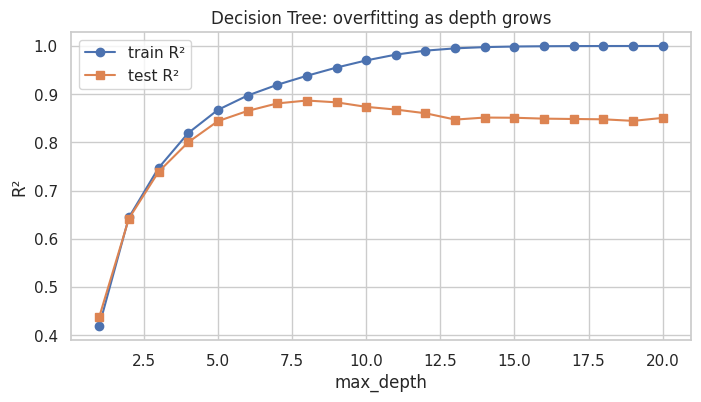

Best depth (for illustration): 8


In [10]:
tree_full = evaluate('Decision Tree (no limit)', Pipeline([('prep', prep_tree), ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))]))

depths = range(1, 21)
train_r2, test_r2 = [], []
for d in depths:
    m = Pipeline([('prep', prep_tree), ('model', DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE))])
    m.fit(X_train, y_train)
    train_r2.append(r2_score(y_train, m.predict(X_train)))
    test_r2.append(r2_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(depths, train_r2, 'o-', label='train R²')
plt.plot(depths, test_r2, 's-', label='test R²')
plt.xlabel('max_depth'); plt.ylabel('R²'); plt.title('Decision Tree: overfitting as depth grows')
plt.legend(); plt.show()

best_depth = depths[int(np.argmax(test_r2))]
print('Best depth (for illustration):', best_depth)

In [11]:
tree = evaluate('Decision Tree (max_depth=6)', Pipeline([('prep', prep_tree), ('model', DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE))]))

Decision Tree (max_depth=6)  train R2=0.897 | test R2=0.865 | MAE=6.33 | RMSE=8.14


**Conclusion:** A tree with no depth limit reaches **train R² = 1.00** but only **0.84 on the test set**, which is classic **overfitting**: it memorises the training data. As depth increases, train R² keeps rising, while test R² peaks at around depth 8 (≈ 0.89) and then falls. Even the best single tree is worse than Linear Regression here.

> Ở đây mình chọn `max_depth` bằng cách nhìn test set **chỉ để minh họa**. Làm như vậy trong dự án thật là sai (test set bị dùng để chọn model → kết quả cuối bị "đẹp" giả). Cách đúng là dùng cross-validation trên train (mục 9–10).

> **Cách đọc biểu đồ overfitting:** khoảng cách giữa đường train và test càng lớn → overfitting càng nặng.
> - Train thấp, test thấp → **underfitting** (model quá đơn giản).
> - Train cao, test thấp → **overfitting** (model quá phức tạp).
> - Cả hai cao và gần nhau → vừa đủ.

## 7.2. Random Forest

> **Random Forest** = trồng **nhiều cây** (ví dụ 300), mỗi cây học trên một mẫu ngẫu nhiên của dữ liệu và một phần ngẫu nhiên của feature, rồi **lấy trung bình**. Nhiều cây "bỏ phiếu" giúp giảm overfitting rất nhiều so với 1 cây.

In [12]:
rf = evaluate('Random Forest', Pipeline([('prep', prep_tree),
              ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]))

Random Forest                train R2=0.991 | test R2=0.924 | MAE=4.71 | RMSE=6.10


## 7.3. Gradient Boosting

> **Gradient Boosting** cũng dùng nhiều cây, nhưng trồng **lần lượt**: mỗi cây mới học cách **sửa lỗi** của các cây trước. Đây thường là model mạnh nhất cho dữ liệu dạng bảng (XGBoost, LightGBM, CatBoost đều thuộc họ này). `HistGradientBoostingRegressor` là phiên bản nhanh có sẵn trong scikit-learn.

In [13]:
gb = evaluate('Gradient Boosting', Pipeline([('prep', prep_tree),
              ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))]))

Gradient Boosting            train R2=0.965 | test R2=0.929 | MAE=4.57 | RMSE=5.89


**Conclusion:** Both ensemble models beat Linear Regression. Gradient Boosting has the best test result so far (lowest MAE and RMSE). Random Forest has a large train–test gap (train R² ≈ 0.99), so it overfits more.

# 8. Bonus: a simple neural network

> **MLP (Multi-Layer Perceptron)** là neural network cơ bản nhất – nền tảng của deep learning. Dữ liệu đi qua các lớp neuron: `input → hidden layer (64) → hidden layer (32) → output`. Mỗi neuron tính tổng có trọng số rồi qua một hàm phi tuyến (ReLU).
> - **Bắt buộc** scale dữ liệu.
> - `early_stopping=True`: tự dừng khi điểm trên một phần dữ liệu kiểm tra không còn cải thiện, giúp tránh overfitting.
> - Với dữ liệu bảng nhỏ như thế này, neural network **thường không thắng** Gradient Boosting. Deep learning mạnh nhất với ảnh, văn bản, âm thanh.

In [14]:
mlp = evaluate('Neural Network (MLP)', Pipeline([('prep', prep_linear),
               ('model', MLPRegressor(hidden_layer_sizes=(64, 32), early_stopping=True,
                                      max_iter=1000, random_state=RANDOM_STATE))]))

Neural Network (MLP)         train R2=0.933 | test R2=0.921 | MAE=4.94 | RMSE=6.23


**Conclusion:** The neural network (test R² = 0.92, MAE = 4.94) is better than Linear Regression, because it can learn non-linear patterns, but it is slightly worse than Gradient Boosting. On small tabular data, tree ensembles are usually the stronger choice.

# 9. Compare models with cross-validation

> Một lần chia train/test có thể "may mắn" hoặc "xui". **K-fold cross-validation** chia **train set** thành 5 phần; lần lượt dùng 4 phần để học và 1 phần để kiểm tra → được 5 điểm số. Ta lấy **trung bình** (độ chính xác) và **độ lệch chuẩn** (độ ổn định).
> 
> ```
> Fold 1: [TEST][train][train][train][train]
> Fold 2: [train][TEST][train][train][train]
> ...     (test set thật vẫn được cất riêng)
> ```
> Đây là cách **đúng** để chọn model.

In [15]:
models = {
    'Baseline'          : DummyRegressor(),
    'Linear (4 key)'    : Pipeline([('prep', prep_key), ('model', LinearRegression())]),
    'Linear (all)'      : Pipeline([('prep', prep_linear), ('model', LinearRegression())]),
    'Lasso (all)'       : Pipeline([('prep', prep_linear), ('model', Lasso(alpha=0.1))]),
    'Decision Tree'     : Pipeline([('prep', prep_tree), ('model', DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE))]),
    'Random Forest'     : Pipeline([('prep', prep_tree), ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]),
    'Gradient Boosting' : Pipeline([('prep', prep_tree), ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
    'Neural Network'    : Pipeline([('prep', prep_linear), ('model', MLPRegressor(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=1000, random_state=RANDOM_STATE))]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in models.items():
    s = cross_validate(model, X_train, y_train, cv=cv,
                       scoring={'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'})
    rows.append({'model': name,
                 'CV_RMSE': -s['test_rmse'].mean(), 'CV_RMSE_std': s['test_rmse'].std(),
                 'CV_MAE': -s['test_mae'].mean(), 'CV_R2': s['test_r2'].mean()})

cv_table = pd.DataFrame(rows).sort_values('CV_RMSE').round(3)
cv_table

,model,CV_RMSE,CV_RMSE_std,CV_MAE,CV_R2
6,Gradient Boosting,5.671,0.074,4.455,0.935
5,Random Forest,5.855,0.057,4.615,0.931
7,Neural Network,5.957,0.051,4.739,0.928
1,Linear (4 key),6.587,0.028,5.236,0.912
3,Lasso (all),6.590,0.026,5.244,0.912
2,Linear (all),6.596,0.025,5.240,0.912
4,Decision Tree,7.921,0.113,6.233,0.873
0,Baseline,22.274,0.196,18.592,-0.000


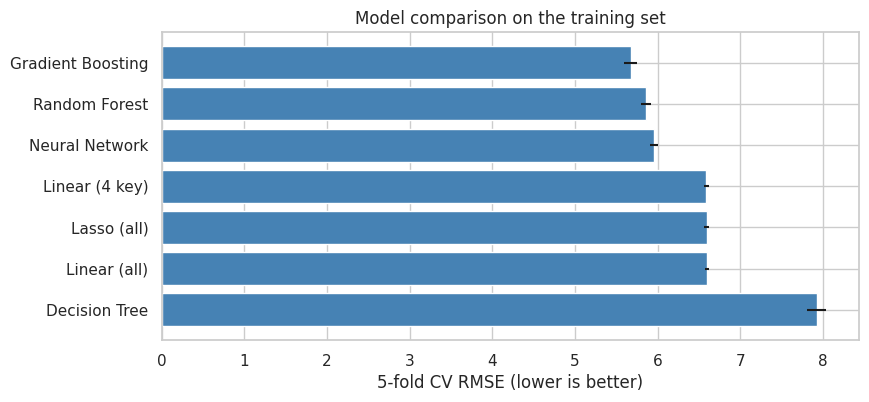

In [16]:
plt.figure(figsize=(9, 4))
plot_data = cv_table[cv_table['model'] != 'Baseline']
plt.barh(plot_data['model'], plot_data['CV_RMSE'], xerr=plot_data['CV_RMSE_std'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('5-fold CV RMSE (lower is better)')
plt.title('Model comparison on the training set')
plt.show()

**Conclusion:** With 5-fold cross-validation, **Gradient Boosting is the best model** (CV RMSE = 5.67, R² = 0.935), followed by Random Forest (5.86) and the Neural Network (5.96). The three linear models are almost identical (RMSE ≈ 6.59, R² = 0.912). The small standard deviations (< 0.12) show that the ranking is **stable** across folds. The CV ranking matches the single test split, so the earlier results were not due to luck.

> **Tại sao model cây thắng?** EDA đã chỉ ra 2 điều mà đường thẳng không mô tả được: **trần 100 điểm** và **tương tác** study × gaming. Model cây tự học được các "đường cong" này. Nhưng Linear chỉ kém khoảng 0.9 điểm RMSE mà lại dễ giải thích hơn nhiều. Trong thực tế, lựa chọn phụ thuộc vào việc bạn cần **độ chính xác** hay **khả năng giải thích**.

# 10. Hyperparameter tuning

> **Hyperparameter** = "nút vặn" bạn đặt **trước** khi train (ví dụ `learning_rate`, `max_depth`), khác với **parameter** mà model tự học (hệ số, cách chia cây).
> 
> **`GridSearchCV`** thử **mọi tổ hợp** trong lưới, đánh giá mỗi tổ hợp bằng cross-validation, rồi chọn tổ hợp tốt nhất. Tên tham số trong Pipeline viết dạng `<tên bước>__<tên tham số>`, ví dụ `model__max_depth`.

In [17]:
param_grid = {
    'model__learning_rate': [0.03, 0.1],
    'model__max_depth'    : [3, None],
    'model__max_iter'     : [200, 400],
}
grid = GridSearchCV(models['Gradient Boosting'], param_grid, cv=cv,
                    scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best parameters :', grid.best_params_)
print(f'Best CV RMSE    : {-grid.best_score_:.3f}')
best_model = grid.best_estimator_      # already refit on the whole training set

Best parameters : {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__max_iter': 400}
Best CV RMSE    : 5.586


**Conclusion:** The best settings are a **smaller learning rate (0.03), shallow trees (max_depth = 3) and more iterations (400)**. Tuning reduced the CV RMSE only a little (from 5.67 to 5.59). This is common: good default settings are often close to optimal, and **better features or cleaner data usually help more than tuning**.

# 11. Final evaluation on the test set

> Đây là lần **duy nhất** ta dùng test set để báo cáo. Ta so sánh model tốt nhất (Gradient Boosting đã tinh chỉnh) với Linear Regression (model đơn giản, dễ giải thích).

In [18]:
final = {}
for name, model in [('Linear (4 key)', lin_key), ('Gradient Boosting (tuned)', best_model)]:
    pred = model.predict(X_test)
    final[name] = pred
    print(f'{name:26s} R2={r2_score(y_test, pred):.3f} | MAE={mean_absolute_error(y_test, pred):.2f}'
          f' | RMSE={np.sqrt(mean_squared_error(y_test, pred)):.2f} | predictions > 100: {(pred > 100).sum()}')

Linear (4 key)             R2=0.902 | MAE=5.51 | RMSE=6.93 | predictions > 100: 87
Gradient Boosting (tuned)  R2=0.930 | MAE=4.63 | RMSE=5.88 | predictions > 100: 47


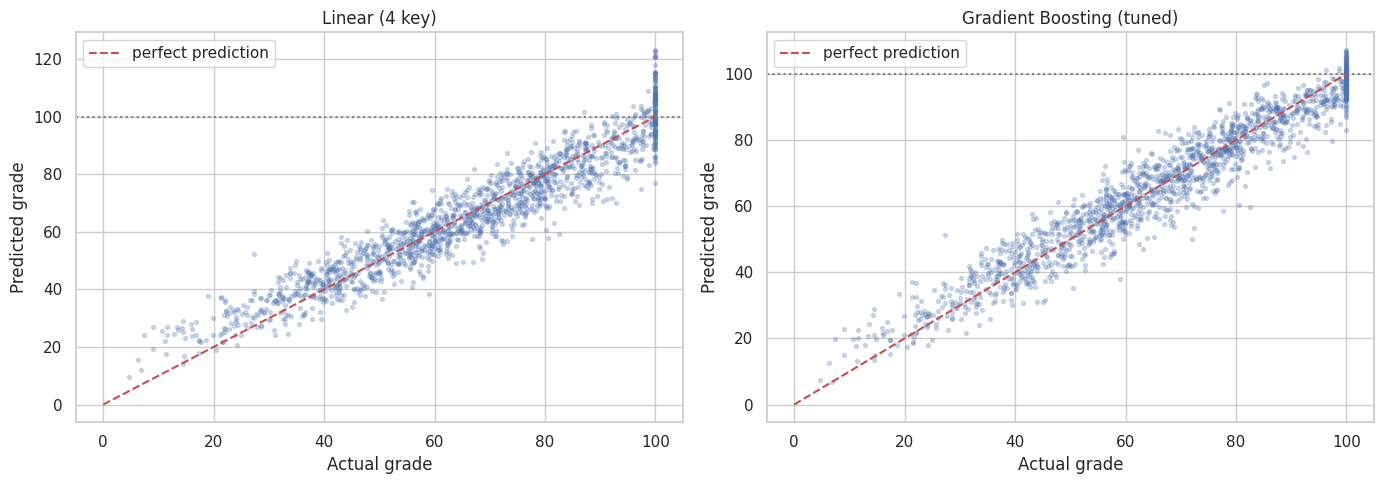

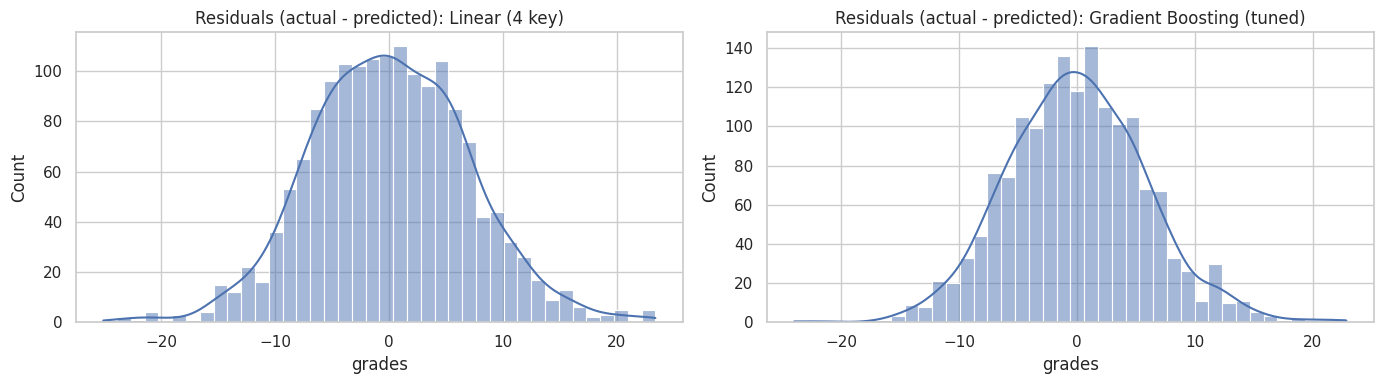

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, pred) in zip(axes, final.items()):
    ax.scatter(y_test, pred, alpha=0.25, s=8)
    ax.plot([0, 100], [0, 100], 'r--', label='perfect prediction')
    ax.axhline(100, color='gray', ls=':')
    ax.set_xlabel('Actual grade'); ax.set_ylabel('Predicted grade')
    ax.set_title(name); ax.legend()
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (name, pred) in zip(axes, final.items()):
    sns.histplot(y_test - pred, bins=40, kde=True, ax=ax)
    ax.set_title(f'Residuals (actual - predicted): {name}')
plt.tight_layout(); plt.show()

In [20]:
# Simple post-processing: a grade cannot be outside [0, 100]
def predict_grade(model, X_new):
    return np.clip(model.predict(X_new), 0, 100)

for name, model in [('Linear (4 key)', lin_key), ('Gradient Boosting (tuned)', best_model)]:
    pred = predict_grade(model, X_test)
    print(f'{name:26s} clipped -> R2={r2_score(y_test, pred):.3f} | MAE={mean_absolute_error(y_test, pred):.2f}'
          f' | RMSE={np.sqrt(mean_squared_error(y_test, pred)):.2f}')

Linear (4 key)             clipped -> R2=0.913 | MAE=5.09 | RMSE=6.54
Gradient Boosting (tuned)  clipped -> R2=0.930 | MAE=4.55 | RMSE=5.85


**Conclusion:**
- On unseen test data, the tuned **Gradient Boosting** model predicts grades with an average error of **4.6 points** (MAE; RMSE = 5.9, R² = 0.93). **Linear Regression** is about 0.9 points worse (MAE = 5.5, R² = 0.90).
- Both models sometimes predict **more than 100** (87 linear and 47 boosting predictions), because the real grades are capped at 100. In the scatter plots, students with an actual grade of exactly 100 form a **vertical column** of predictions (up to about 120 for the linear model): their "true" grade was probably higher but was capped. This is the **ceiling effect** found in the EDA. The linear model also slightly over-predicts the lowest grades, while Gradient Boosting follows the diagonal more closely.
- **Clipping predictions to [0, 100]** is a simple fix. It clearly helps the linear model (MAE 5.51 → 5.09) and slightly helps Gradient Boosting.
- Residuals of both models are centred on 0 and roughly bell-shaped, so there is no large systematic bias.

# 12. Model interpretation: permutation importance

> **Permutation importance**: xáo trộn ngẫu nhiên một cột trong test set rồi xem lỗi của model **tăng bao nhiêu**. Cột càng quan trọng thì khi bị xáo trộn, model càng dự đoán sai nhiều. Cách này dùng được cho **mọi model**, kể cả model "hộp đen" như Gradient Boosting.

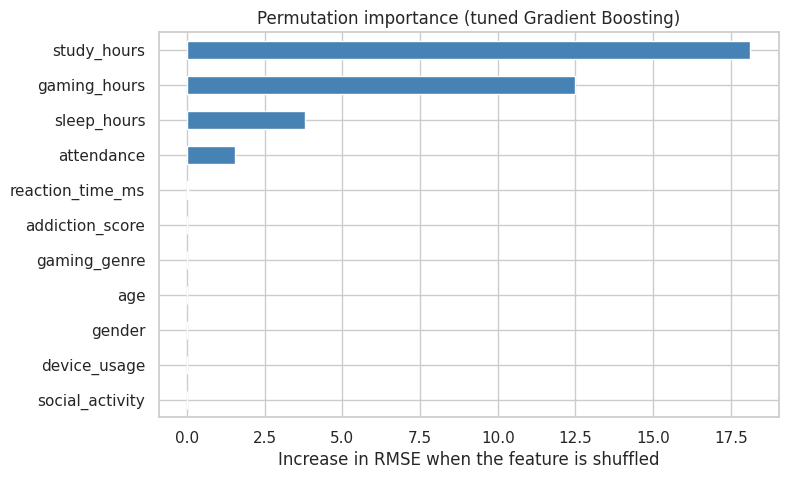

,RMSE increase
study_hours,18.13
gaming_hours,12.48
sleep_hours,3.81
attendance,1.56
reaction_time_ms,0.03
addiction_score,0.01
gaming_genre,0.00
age,0.00
gender,0.00
device_usage,-0.01


In [21]:
imp = permutation_importance(best_model, X_test, y_test, n_repeats=10,
                             random_state=RANDOM_STATE, scoring='neg_root_mean_squared_error')
importance = pd.Series(imp.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(8, 5))
importance.plot.barh(color='steelblue')
plt.xlabel('Increase in RMSE when the feature is shuffled')
plt.title('Permutation importance (tuned Gradient Boosting)')
plt.show()
importance.sort_values(ascending=False).round(2).to_frame('RMSE increase')

**Conclusion:** When `study_hours` is shuffled, the RMSE rises by about **18 points**, and by about **12 points** for `gaming_hours`. `sleep_hours` (≈ 3.8) and `attendance` (≈ 1.6) matter less, and all other features have an importance close to **0**. Even a flexible model uses only the **same 4 features** found in the EDA and by Lasso. Three different methods agree, which makes this conclusion strong.

# 13. Predict grades for new students

> Đây là mục đích cuối cùng: đưa thông tin **học sinh mới** vào và nhận dự đoán. Dữ liệu mới phải có **cùng tên cột** như lúc train. Nhờ `Pipeline`, bạn không cần tự scale hay encode: model tự làm.

In [22]:
new_students = pd.DataFrame([
    # a hard-working student who games little
    {'age': 20, 'gender': 'Female', 'gaming_hours': 1.0, 'study_hours': 8.0, 'sleep_hours': 7.5,
     'attendance': 92, 'gaming_genre': 'Casual', 'social_activity': 2.0, 'device_usage': 4.0,
     'reaction_time_ms': 305, 'addiction_score': 3.0},
    # a heavy gamer who studies little
    {'age': 19, 'gender': 'Male', 'gaming_hours': 7.0, 'study_hours': 2.0, 'sleep_hours': 5.0,
     'attendance': 65, 'gaming_genre': 'FPS', 'social_activity': 1.0, 'device_usage': 11.0,
     'reaction_time_ms': 235, 'addiction_score': 16.0},
    # an average student
    {'age': 21, 'gender': 'Other', 'gaming_hours': 4.0, 'study_hours': 5.5, 'sleep_hours': 6.5,
     'attendance': 80, 'gaming_genre': 'RPG', 'social_activity': 2.5, 'device_usage': 7.5,
     'reaction_time_ms': 270, 'addiction_score': 10.0},
])

new_students['pred_linear'] = predict_grade(lin_key, new_students).round(1)
new_students['pred_gboost'] = predict_grade(best_model, new_students).round(1)
new_students[['gaming_hours', 'study_hours', 'sleep_hours', 'attendance', 'pred_linear', 'pred_gboost']]

,gaming_hours,study_hours,sleep_hours,attendance,pred_linear,pred_gboost
0,1.0,8.0,7.5,92,100.0,100.0
1,7.0,2.0,5.0,65,19.3,16.4
2,4.0,5.5,6.5,80,66.8,67.4


In [23]:
# Save the model to a file and load it again later (e.g. in an app)
joblib.dump(best_model, 'grade_model.joblib')
loaded = joblib.load('grade_model.joblib')
print('Loaded model prediction for student 1:', predict_grade(loaded, new_students.iloc[[0]])[0].round(1))

Loaded model prediction for student 1: 100.0


**Conclusion:** The model gives sensible predictions: about **100** for the hard-working student, about **16–19** for the heavy gamer who studies little, and about **67** for the average student. The two models agree closely. Because the model is saved as a file, it can be reused later without retraining.

> **What-if analysis:** bạn có thể dùng model để hỏi "nếu học sinh 2 giảm 3 giờ chơi game thì điểm dự đoán thay đổi thế nào?". Hãy nhớ đây là **dự đoán dựa trên tương quan**, không chứng minh được quan hệ nhân quả.

# 14. Bonus: classification – identify at-risk students

> Giả sử nhà trường muốn **phát hiện sớm học sinh có nguy cơ điểm thấp** (< 50) để hỗ trợ. Target giờ là **nhãn 0/1** → bài toán **classification**.
> 
> Khác biệt so với regression:
> - Model: `LogisticRegression`, `RandomForestClassifier`, ...
> - `stratify=y` khi chia để tỷ lệ 0/1 trong train và test giống nhau.
> - Metric khác: accuracy, precision, recall, F1, confusion matrix.

In [24]:
y_cls = (df[target] < 50).astype(int)          # 1 = at risk
print(y_cls.value_counts(normalize=True).rename({0: 'not at risk', 1: 'at risk'}).round(3))

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls)

log_reg = Pipeline([('prep', prep_linear), ('model', LogisticRegression(max_iter=1000))]).fit(Xc_train, yc_train)
rf_cls  = Pipeline([('prep', prep_tree), ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]).fit(Xc_train, yc_train)

for name, m in [('Logistic Regression', log_reg), ('Random Forest', rf_cls)]:
    print(f'===== {name} =====')
    print(classification_report(yc_test, m.predict(Xc_test), target_names=['not at risk', 'at risk'], digits=3))

grades
not at risk    0.749
at risk        0.251
Name: proportion, dtype: float64


===== Logistic Regression =====
              precision    recall  f1-score   support

 not at risk      0.957     0.965     0.961      1198
     at risk      0.893     0.871     0.882       402

    accuracy                          0.941      1600
   macro avg      0.925     0.918     0.921      1600
weighted avg      0.941     0.941     0.941      1600

===== Random Forest =====
              precision    recall  f1-score   support

 not at risk      0.950     0.969     0.960      1198
     at risk      0.902     0.848     0.874       402

    accuracy                          0.939      1600
   macro avg      0.926     0.909     0.917      1600
weighted avg      0.938     0.939     0.938      1600



**Đọc classification report** (với lớp "at risk"):

| Metric | Câu hỏi nó trả lời |
| --- | --- |
| **Precision** | Trong các em model báo "at risk", bao nhiêu % thật sự at risk? (báo động nhầm ít không?) |
| **Recall** | Trong các em thật sự at risk, model tìm ra được bao nhiêu %? (có bỏ sót không?) |
| **F1** | Trung bình điều hòa của precision và recall |
| **Accuracy** | % dự đoán đúng tổng thể. Dễ gây hiểu lầm khi dữ liệu mất cân bằng: đoán "not at risk" cho tất cả đã đúng ~75% |

Với bài toán hỗ trợ học sinh, **bỏ sót** một em at risk thường tệ hơn **báo nhầm**, nên **recall** quan trọng hơn.

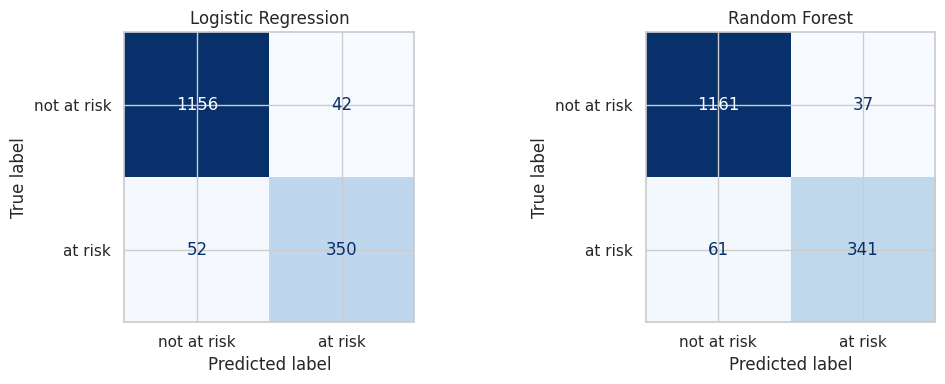

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, m) in zip(axes, [('Logistic Regression', log_reg), ('Random Forest', rf_cls)]):
    ConfusionMatrixDisplay.from_estimator(m, Xc_test, yc_test, display_labels=['not at risk', 'at risk'],
                                          cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

In [26]:
# Lower the decision threshold to catch more at-risk students (higher recall, lower precision)
proba = log_reg.predict_proba(Xc_test)[:, 1]
rows = []
for t in [0.5, 0.4, 0.3, 0.2]:
    pred = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yc_test, pred).ravel()
    rows.append({'threshold': t, 'precision': tp / (tp + fp), 'recall': tp / (tp + fn),
                 'missed at-risk (FN)': fn, 'false alarms (FP)': fp})
pd.DataFrame(rows).round(3)

,threshold,precision,recall,missed at-risk (FN),false alarms (FP)
0,0.5,0.893,0.871,52,42
1,0.4,0.854,0.900,40,62
2,0.3,0.817,0.923,31,83
3,0.2,0.767,0.943,23,115


**Conclusion:**
- 25.1% of students are at risk (grade < 50). **Logistic Regression** reaches **94.1% accuracy** and finds **87.1% of at-risk students** (recall) with 89.3% precision. It is slightly better than Random Forest (recall 84.8%), so a simple model can be the best choice.
- Lowering the decision threshold from 0.5 to 0.3 raises recall to **92.3%** (missed students drop from 52 to 31), but false alarms rise from 42 to 83. The school should choose the threshold based on the **cost of missing a student vs. the cost of an unnecessary intervention**.

# 15. Summary

**Final test-set results (all models, for reference):**

In [27]:
pd.DataFrame(results).sort_values('test_RMSE').round(3).reset_index(drop=True)

,model,train_R2,test_R2,test_MAE,test_RMSE
0,Gradient Boosting,0.965,0.929,4.569,5.887
1,Random Forest,0.991,0.924,4.706,6.102
2,Neural Network (MLP),0.933,0.921,4.936,6.233
3,"Lasso (all, alpha=0.1)",0.913,0.902,5.509,6.930
4,Linear (4 key features),0.913,0.902,5.507,6.934
5,"Ridge (all, alpha=10)",0.913,0.902,5.513,6.937
6,Linear (all features),0.913,0.902,5.514,6.940
7,Decision Tree (max_depth=6),0.897,0.865,6.326,8.135
8,Decision Tree (no limit),1.000,0.842,6.722,8.803
9,Baseline (predict mean),0.000,-0.000,18.420,22.164


**Key findings**
1. All models beat the baseline (MAE 18.4) by a large margin. The **tuned Gradient Boosting model is the most accurate** (test MAE ≈ 4.6, R² = 0.93), and **Linear Regression** is a strong, easy-to-explain alternative (MAE ≈ 5.1 and R² = 0.91 after clipping).
2. Only **4 features matter**: study hours, gaming hours, sleep hours and attendance. EDA, Lasso and permutation importance all agree.
3. Tree ensembles win because they capture the **ceiling at 100** and the **study × gaming interaction** that a straight line cannot model.
4. For the classification task, **Logistic Regression** identifies 87% of at-risk students at the default threshold, and more if the threshold is lowered.

**Limitations**
- The data is very likely synthetic, so the high R² (≈ 0.93) would probably be much lower on real student data.
- The models show **associations, not causes**: they predict grades, but do not prove that changing a habit will change a grade.

**Next steps**
- Try XGBoost / LightGBM, and use `RandomizedSearchCV` for larger search spaces.
- Use SHAP values to explain individual predictions.
- Build a deep learning model with PyTorch or Keras (MLP) to practise the training loop, loss and epochs.

## Bài tập tự luyện

1. Chọn `max_depth` cho Decision Tree bằng `GridSearchCV` (không dùng test set). Kết quả có giống depth ≈ 8 không?
2. Thêm feature mới `total_hours = gaming + study + sleep` hoặc `study_x_gaming = study_hours * gaming_hours` vào Linear Regression. RMSE có giảm không? Vì sao?
3. Thử đưa `stress_level` vào model (dạng số 1–2–3). Điểm tăng bao nhiêu? Giải thích bằng khái niệm **data leakage**.
4. Train lại các model **không clip** `grades` (dùng file gốc). Kết quả thay đổi ra sao?
5. Bài classification: dùng `class_weight='balanced'` trong `LogisticRegression` và so sánh recall với cách hạ threshold.
6. Viết một đoạn report 150–200 từ bằng tiếng Anh, tóm tắt mục 9–11, theo mẫu câu trong tài liệu "Lộ trình EDA".